<a href="https://colab.research.google.com/github/JoyIbeh/Assignment-one/blob/main/Ibeh_Joy_Question_Mini_Project_Module_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COVID-19 Data Analysis: Exploring Trends, Vaccination Impact, and Insights Through Visualizations

The COVID-19 pandemic, caused by the SARS-CoV-2 virus, has significantly impacted global health, economies, and daily life. Since its emergence in late 2019, vast amounts of data have been collected on infection rates, mortality, vaccination efforts, and testing strategies. Analyzing this data is crucial for understanding the spread of the virus, identifying trends, and making informed policy decisions. This project involves basic data cleaning, exploratory data analysis (EDA), and visualization to uncover insights into COVID-19 cases, deaths, and vaccinations over time.

## About the Dataset

The **[dataset](https://drive.google.com/file/d/1syeD6Ni_ZlfXHHH0Jp6ALpvg9iCAEk_-/view?usp=sharing)** used for this project contains essential COVID-19 metrics, tracking the progression of the pandemic across different countries. The dataset consists of the following columns:

- DATE: The recorded date of COVID-19 data entry.
- country: The country or region where the cases, deaths, and vaccinations were reported.
- NEW Cases: The number of newly confirmed COVID-19 cases reported on a given date.
- NEW_DEATHS: The number of new deaths attributed to COVID-19 on that specific date.
- vaccinated: The number of people who have received at least one dose of the COVID-19 vaccine.

This dataset may require cleaning and preprocessing to handle missing values, incorrect formats, and inconsistencies before conducting meaningful analysis.

## Objective

The primary goal of this mini-project is to clean, analyze, and visualize COVID-19 data to identify trends, patterns, and key insights. The specific objectives include:

- Perform Data Cleaning: Handle missing values, standardize date formats, and filter out inconsistencies.
- Explore Trends in COVID-19 Cases and Deaths:
  - Analyze daily and cumulative trends in infections and fatalities.
  - Compare case and death rates across different countries and regions.
- Create Data Visualizations:
  - Line Plots: Show the trend of cases, deaths, and vaccinations over time.
  - Bar Charts: Compare cases, deaths, and vaccinations by country.
  - Scatter Plots: Explore relationships between infection rates and testing or vaccination rates.

In [ ]:
# Solution

In [ ]:
# Loading the dataset and importing the libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

covid_data = pd.read_csv('/content/sample_data/covid_19.csv')

In [ ]:
# printing the first information to understand the data
covid_data.head()

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated
0,2024-11-01,Argentina,NaN,NaN,unknown
1,2024-11-01,Australia,0.0,0.0,327
2,2024-11-01,Australia,0.0,0.0,327
3,2024-11-01,Brazil,971.0,48.0,430
4,2024-11-01,Canada,176.0,8.0,unknown


In [ ]:
# Data Pre-processing and Cleaning

In [ ]:
covid_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   DATE        165 non-null    object 
 1   country     165 non-null    object 
 2   NEW Cases   154 non-null    float64
 3   NEW_DEATHS  139 non-null    float64
 4   vaccinated  165 non-null    object 
dtypes: float64(2), object(3)
memory usage: 6.6+ KB


In [ ]:
covid_data.describe()

,NEW Cases,NEW_DEATHS
count,154.000000,139.000000
mean,579.032468,28.474820
std,406.078350,20.640586
min,0.000000,0.000000
25%,271.750000,13.500000
50%,589.000000,29.000000
75%,801.250000,39.500000
max,1730.000000,86.000000


In [ ]:
covid_data.isnull().sum()

,0
DATE,0
country,0
NEW Cases,11
NEW_DEATHS,26
vaccinated,0


In [ ]:
# Using the mean to fill up the death and the missing values means assuming,
# in this case i am going to fill it with zero to assume that no report was received row with missing values
covid_data["NEW Cases"] = covid_data["NEW Cases"].fillna(0)
covid_data["NEW_DEATHS"] = covid_data["NEW_DEATHS"].fillna(0)
covid_data["vaccinated"] = covid_data["vaccinated"].replace('unknown',int(0))

In [ ]:
covid_data.isnull().sum()

,0
DATE,0
country,0
NEW Cases,0
NEW_DEATHS,0
vaccinated,0


In [ ]:
# Checking for duplicates

covid_data.duplicated().sum()


np.int64(15)

In [ ]:
# dropping duplicate
covid_data.drop_duplicates(inplace=True)

In [ ]:
# Checking for unique items
covid_data.nunique()

,0
DATE,42
country,5
NEW Cases,124
NEW_DEATHS,61
vaccinated,117


In [ ]:
# Converting the DATE Column to date
covid_data["DATE"] = pd.to_datetime(covid_data["DATE"], errors="coerce")

In [ ]:
# Extract year, full month name, and weekday name
covid_data["Year"] = covid_data["DATE"].dt.year
covid_data["Month"] = covid_data["DATE"].dt.strftime("%B")   # Full month name
covid_data["Day"] = covid_data["DATE"].dt.strftime("%A")     # Full weekday name

In [ ]:
covid_data

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated,Year,Month,Day
0,2024-11-01,Argentina,0.0,0.0,0,2024.0,November,Friday
1,2024-11-01,Australia,0.0,0.0,327,2024.0,November,Friday
3,2024-11-01,Brazil,971.0,48.0,430,2024.0,November,Friday
4,2024-11-01,Canada,176.0,8.0,0,2024.0,November,Friday
5,2024-11-01,China,1034.0,51.0,462,2024.0,November,Friday
...,...,...,...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,0,2024.0,November,Saturday
159,2024-11-30,Australia,1473.0,73.0,428,2024.0,November,Saturday
160,2024-11-30,Brazil,514.0,25.0,0,2024.0,November,Saturday
161,2024-11-30,Canada,1133.0,56.0,438,2024.0,November,Saturday


Exploring the Trend in Covid 19 Cases

In [ ]:
# 1 Analyze daily and cumulative trends in infections and fatalities i.e.: the cummulative in new cases and in new deaths

In [ ]:
# Compute cumulative cases & deaths per country
covid_data["CUM_CASES"] = covid_data.groupby("country")["NEW Cases"].cumsum()
covid_data["CUM_DEATHS"] = covid_data.groupby("country")["NEW_DEATHS"].cumsum()


In [ ]:
covid_data

,DATE,country,NEW Cases,NEW_DEATHS,vaccinated,Year,Month,Day,CUM_CASES,CUM_DEATHS
0,2024-11-01,Argentina,0.0,0.0,0,2024.0,November,Friday,0.0,0.0
1,2024-11-01,Australia,0.0,0.0,327,2024.0,November,Friday,0.0,0.0
3,2024-11-01,Brazil,971.0,48.0,430,2024.0,November,Friday,971.0,48.0
4,2024-11-01,Canada,176.0,8.0,0,2024.0,November,Friday,176.0,8.0
5,2024-11-01,China,1034.0,51.0,462,2024.0,November,Friday,1034.0,51.0
...,...,...,...,...,...,...,...,...,...,...
158,2024-11-30,Argentina,1619.0,80.0,0,2024.0,November,Saturday,21422.0,961.0
159,2024-11-30,Australia,1473.0,73.0,428,2024.0,November,Saturday,20941.0,862.0
160,2024-11-30,Brazil,514.0,25.0,0,2024.0,November,Saturday,11543.0,521.0
161,2024-11-30,Canada,1133.0,56.0,438,2024.0,November,Saturday,13877.0,605.0


In [ ]:
# Cummulative new cases by county
new_cases_by_country = covid_data.groupby("country")["NEW Cases"].sum()

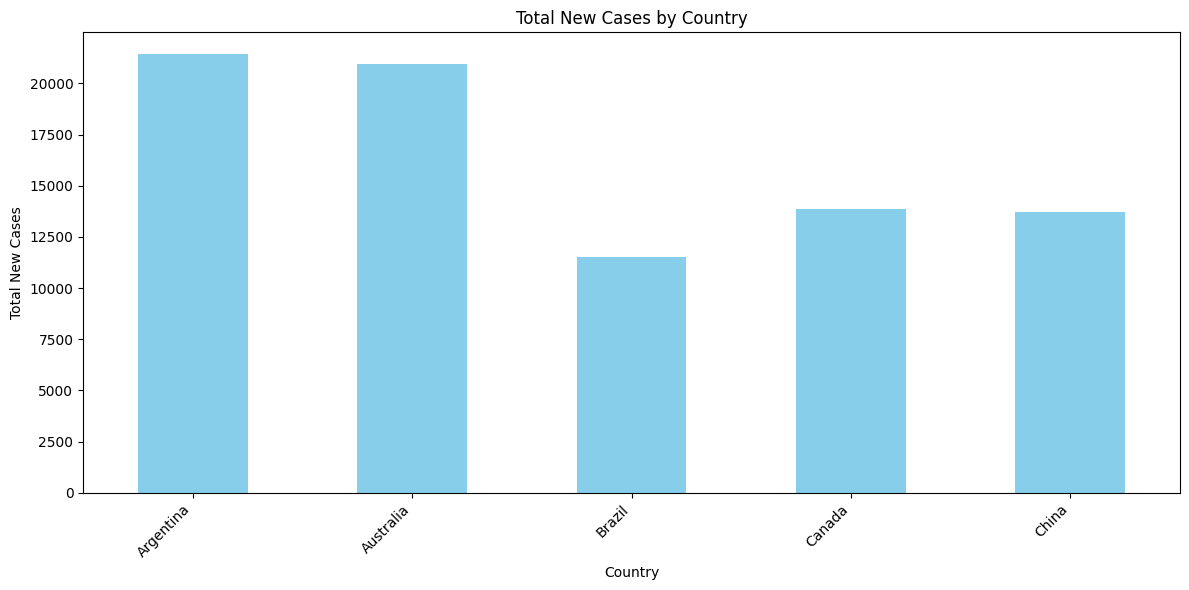

In [ ]:
# Plot graph to display country with the more new cases
plt.figure(figsize=(12, 6))
new_cases_by_country.plot(kind="bar", color="skyblue")
plt.title("Total New Cases by Country")
plt.xlabel("Country")
plt.ylabel("Total New Cases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()


In [ ]:
# Cummulatives Dates by country
death_by_country = covid_data.groupby("country")["NEW_DEATHS"].sum()
death_by_country

,NEW_DEATHS
country,
Argentina,961.0
Australia,862.0
Brazil,521.0
Canada,605.0
China,670.0


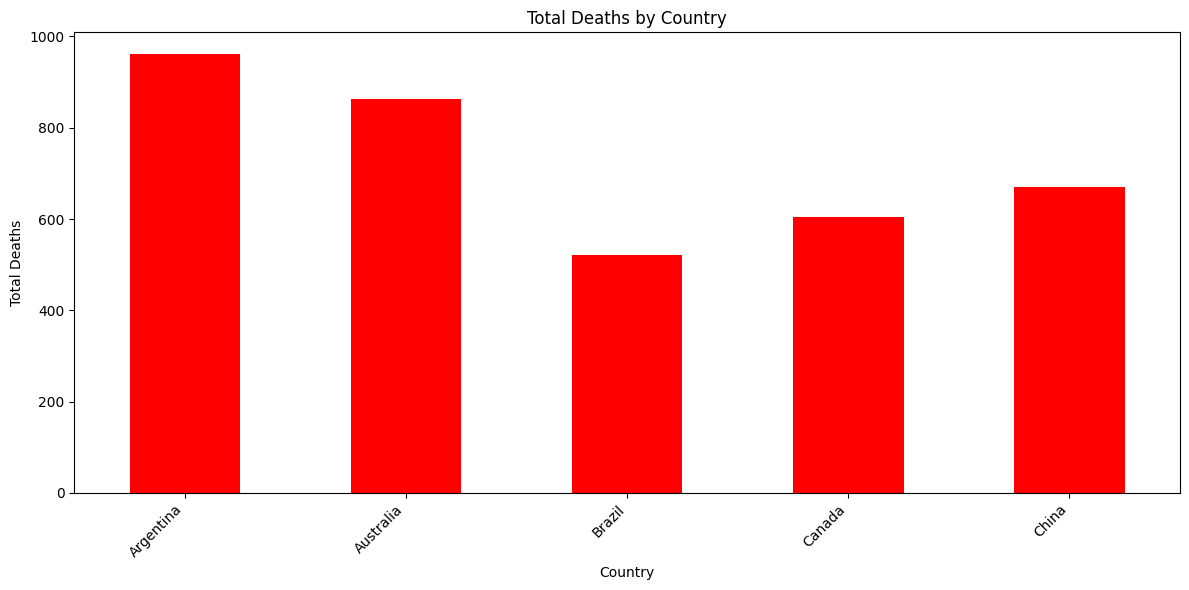

In [ ]:
# Creating a graph of to know the highest rate of death by country
plt.figure(figsize=(12, 6))
death_by_country.plot(kind="bar", color="red")
plt.title("Total Deaths by Country")
plt.xlabel("Country")
plt.ylabel("Total Deaths")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

In [ ]:
# converting the dataype of the vacinated column to numeric data type because
# initially when i ran it i was a giving me a TypeError: unsupported operand type(s) for +: 'int' and 'str'

covid_data['vaccinated'] = pd.to_numeric(covid_data['vaccinated'], errors='coerce')

In [ ]:
# Cummulative Vaccinated by country

vaccinated_by_country = covid_data.groupby("country")["vaccinated"].sum()
vaccinated_by_country

,vaccinated
country,
Argentina,5438
Australia,11948
Brazil,5309
Canada,11762
China,6833


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

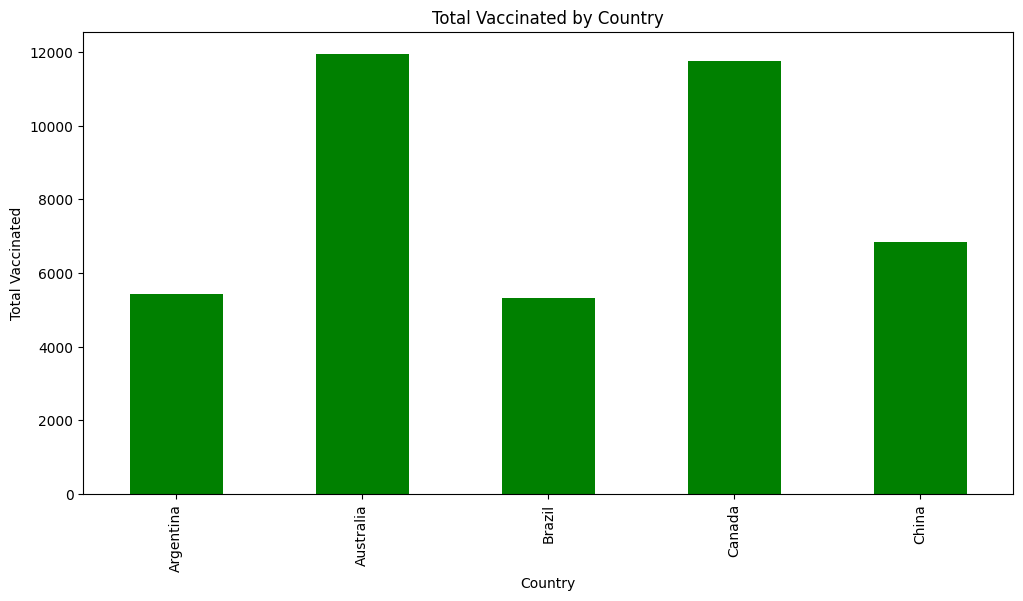

In [ ]:
# Creating a graph of to know the highest rate of vacination received per country by country
plt.figure(figsize=(12, 6))
vaccinated_by_country.plot(kind="bar", color="green")
plt.title("Total Vaccinated by Country")
plt.xlabel("Country")
plt.ylabel("Total Vaccinated")
plt

Since all the received only accounted for november , i grouped the case based on the days and plot a trend line accordingly

In [ ]:
# Cummulative  new cases by Day
New_cases_by_day = covid_data.groupby("Day")["NEW Cases"].sum()
New_cases_by_day

,NEW Cases
Day,
Friday,13430.0
Monday,7106.0
Saturday,13845.0
Sunday,7557.0
Thursday,11548.0
Tuesday,9425.0
Wednesday,8780.0


<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

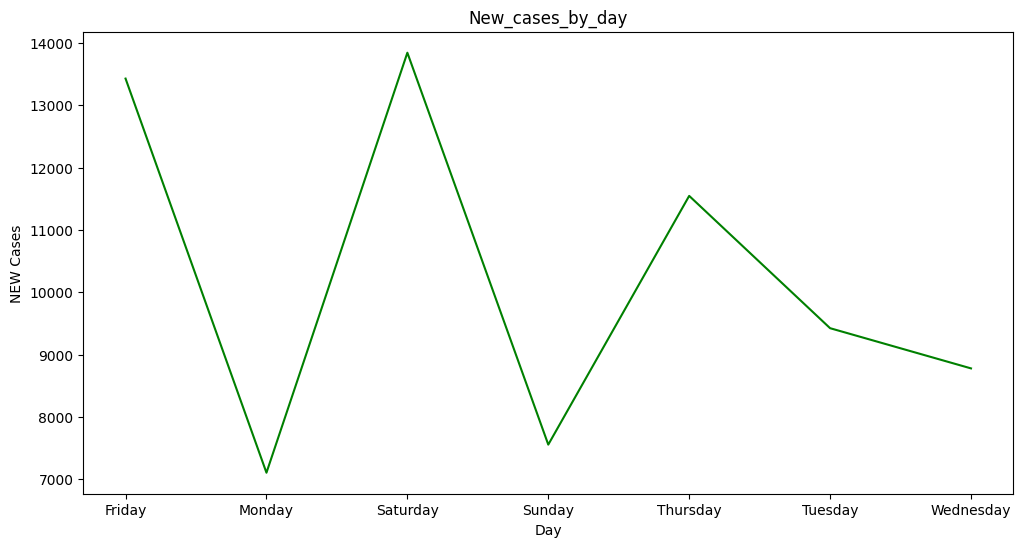

In [ ]:
#  Show the trend of cases, deaths, and vaccinations over time.
plt.figure(figsize=(12, 6))
New_cases_by_day.plot(kind="line", color="green")
plt.title("New_cases_by_day")
plt.xlabel("Day")
plt.ylabel("NEW Cases")
plt

In [ ]:
# Group by Day and country and sum NEW Cases
new_cases_by_day_and_country = covid_data.groupby(["Day", "country"])["NEW Cases"].sum()

# Display the result
display(new_cases_by_day_and_country)

Day        country  
Friday     Argentina    3950.0
           Australia    3474.0
           Brazil       1528.0
           Canada       1961.0
           China        2517.0
Monday     Argentina    1159.0
           Australia    1285.0
           Brazil       1583.0
           Canada        970.0
           China        2109.0
Saturday   Argentina    3965.0
           Australia    2564.0
           Brazil       2259.0
           Canada       2798.0
           China        2259.0
Sunday     Argentina    2381.0
           Australia    1601.0
           Brazil        782.0
           Canada       1885.0
           China         908.0
Thursday   Argentina    2425.0
           Australia    3797.0
           Brazil       2282.0
           Canada       2055.0
           China         989.0
Tuesday    Argentina    2766.0
           Australia    3234.0
           Brazil       1162.0
           Canada        120.0
           China        2143.0
Wednesday  Argentina    2996.0
           Australia    1883.0
           Brazil       1947.0
           Canada        588.0
           China        1366.0
Name: NEW Cases, dtype: float64

In [ ]:
# Cummulative  new cases by Day

vaccinated_by_country = covid_data.groupby("Day")["NEW_DEATHS"].sum()
vaccinated_by_country

,NEW_DEATHS
Day,
Friday,609.0
Monday,304.0
Saturday,681.0
Sunday,270.0
Thursday,532.0
Tuesday,411.0
Wednesday,380.0


<Figure size 1200x600 with 0 Axes>

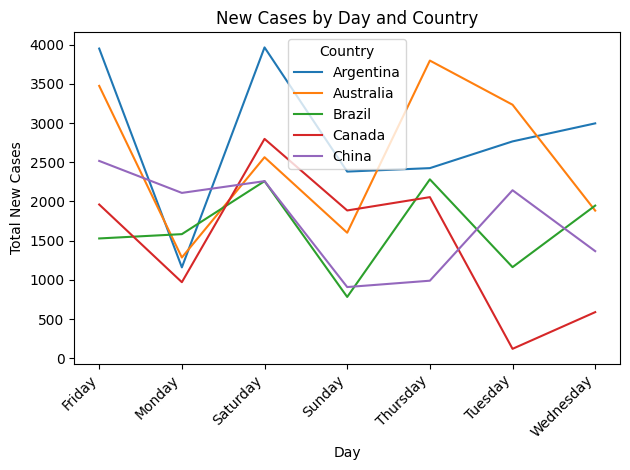

In [ ]:
# Unstack the series to plot lines for each country
new_cases_by_day_and_country_df = new_cases_by_day_and_country.unstack()

# Plotting the grouped line chart
plt.figure(figsize=(12, 6))
new_cases_by_day_and_country_df.plot(kind="line")
plt.title("New Cases by Day and Country")
plt.xlabel("Day")
plt.ylabel("Total New Cases")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Country")
plt.tight_layout()
plt.show()

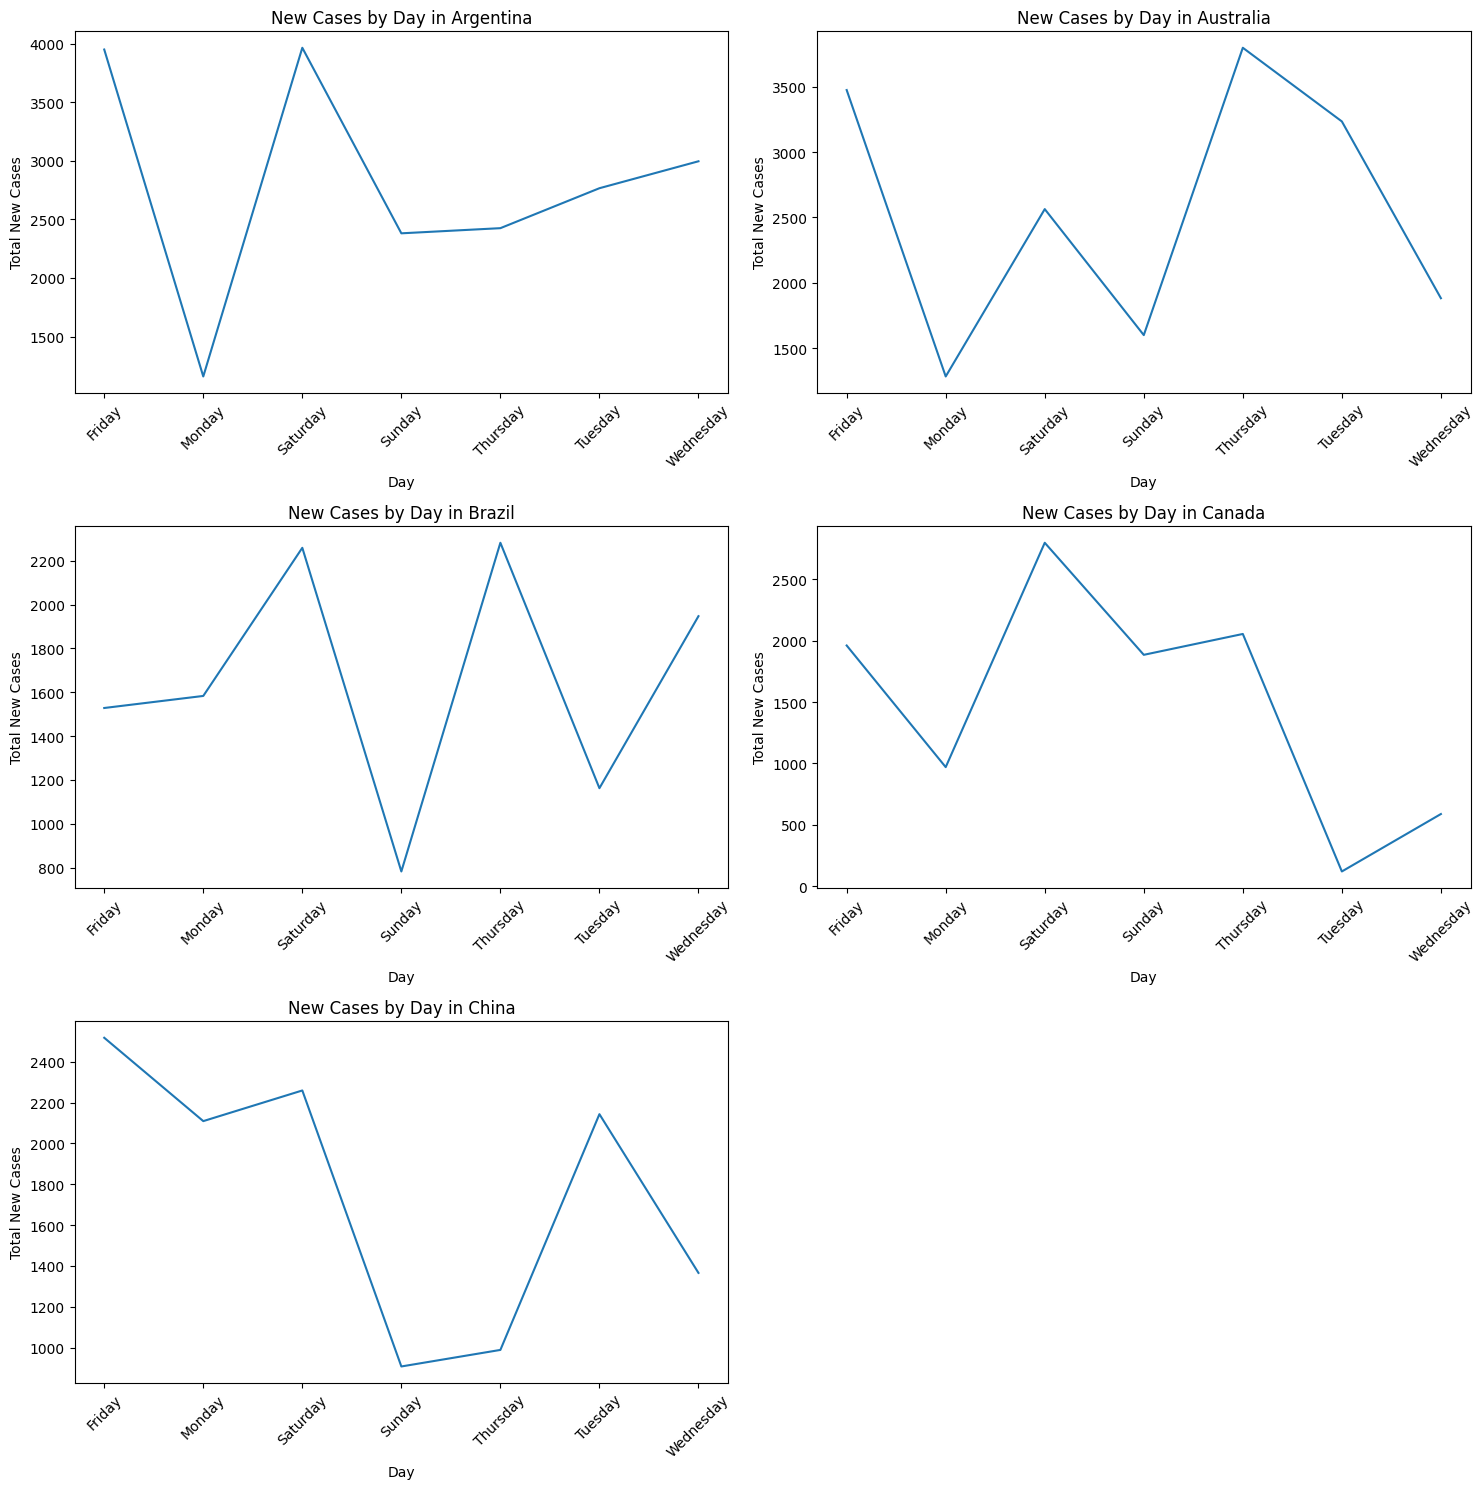

In [ ]:
# Plotting the line charts in a grid format
countries = new_cases_by_day_and_country_df.columns
num_countries = len(countries)
num_cols = 2  # Number of columns in the grid
num_rows = (num_countries + num_cols - 1) // num_cols  # Calculate number of rows

fig, axes = plt.subplots(num_rows, num_cols, figsize=(15, num_rows * 5))

axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

for i, country in enumerate(countries):
    new_cases_by_day_and_country_df[country].plot(kind="line", ax=axes[i])
    axes[i].set_title(f"New Cases by Day in {country}")
    axes[i].set_xlabel("Day")
    axes[i].set_ylabel("Total New Cases")
    axes[i].tick_params(axis='x', rotation=45)

# Hide any unused subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
##  Show the trend of deaths, and the number of days.
